# CE49X Lab 4: Istanbul Earthquake Risk Communication Dashboard
## Visualization for Decision-Makers

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Group Members:**
| Name | Student ID |
|------|------------|
| *(your name)* | *(your ID)* |
| *(partner's name)* | *(partner's ID)* |

## Background

Istanbul sits directly on the **North Anatolian Fault (NAF)**, one of the most active strike-slip faults in the world. The devastating 1999 Izmit earthquake (M7.6) ruptured a segment just 80 km east of the city, and seismologists have long warned that the next major rupture is expected beneath the Sea of Marmara — directly south of Istanbul.

The 2023 Kahramanmaras earthquake sequence (M7.8 + M7.5) demonstrated the catastrophic potential of large earthquakes in Turkey and renewed urgency around earthquake preparedness in Istanbul, a city of over 16 million people.

Effective **risk communication** is critical: decision-makers in municipal government need clear, honest, and actionable visualizations — not just raw data. A misleading colormap or a truncated axis can distort risk perception and lead to poor resource allocation.

> **Key Insight:** Visualization is not decoration — it is a critical tool for communicating risk to non-technical audiences. Every design choice (color, scale, annotation) shapes how decision-makers understand and act on data.

## Scenario

You have been hired as a **visualization consultant** for Istanbul's Disaster Coordination Center (AFAD Istanbul). Your task is to create a set of **publication-quality visualizations** for a risk communication report that will be presented to the **Istanbul Municipal Council** — a non-technical audience of elected officials who must decide how to allocate earthquake preparedness funding across Istanbul's districts.

Your visualizations must be:
- **Accurate** — no misleading scales, truncated axes, or rainbow colormaps
- **Clear** — interpretable by someone without a seismology background
- **Actionable** — each chart should support a specific decision or insight
- **Professional** — publication-ready with proper labels, titles, and annotations

## Data Requirements

You must collect **three categories** of real data. No data files are provided — you are responsible for sourcing, downloading, and documenting your data. For each dataset, record the **source URL**, **date accessed**, **how you obtained it**, and **number of records**.

### 1. Earthquake Catalog (required)

Historical earthquakes for the Marmara region. You need **at least 200 earthquakes** with year, latitude, longitude, depth, and magnitude.

Suggested sources:
- **AFAD Earthquake Department**: [deprem.afad.gov.tr](https://deprem.afad.gov.tr) — Turkey's official earthquake catalog, searchable by region/date/magnitude, downloadable as CSV
- **KOERI (Kandilli Observatory)**: [koeri.boun.edu.tr](http://www.koeri.boun.edu.tr) — Bogazici University's own seismology center
- **USGS Earthquake Catalog**: [earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/) — global catalog, CSV export, filter by lat/lon bounding box (e.g., 40-41.5°N, 27-31°E for the Marmara region)

### 2. Building / Population Data (required)

Istanbul district-level data on buildings and/or population. You need data for **at least 10 Istanbul districts** with population and at least one building-related metric (age, type, or count).

Suggested sources:
- **TUIK (Turkish Statistical Institute)**: [data.tuik.gov.tr](https://data.tuik.gov.tr) — district-level population, building permits, construction statistics
- **IBB Open Data Portal**: [data.ibb.gov.tr](https://data.ibb.gov.tr) — Istanbul municipality datasets on buildings, infrastructure, demographics
- **Wikipedia / official district pages** — acceptable for population/area if properly cited

### 3. Seismic Hazard or Vulnerability Data (required)

Any dataset that allows spatial visualization of earthquake risk. You need spatial risk data covering Istanbul (grid, district-level, or at least 10 data points with coordinates).

Options include:
- **AFAD seismic hazard maps** — PGA (Peak Ground Acceleration) values or seismic zones for Istanbul
- **AFAD/IBB building damage estimates** — expected damage scenarios for a major Marmara earthquake
- **Soil classification maps** from IBB or academic papers
- **Any published risk study** with district-level or grid-level data (can be manually digitized from a figure if necessary)

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Collection & Documentation | 10 | Data sourcing, Pandas loading, `df.head()`, `df.describe()` |
| D2 | Historical Seismicity Timeline | 15 | Scatter with variable size/color, colorbar, `annotate` |
| D3 | Magnitude-Frequency Analysis | 15 | Histogram + KDE, `axvline`, log-plot with linear fit |
| D4 | Building Vulnerability or Population Risk | 15 | Seaborn categorical plots, sorted charts, color encoding |
| D5 | Earthquake Hazard Visualization | 20 | `contourf`/scatter/heatmap, sequential colormap, annotations |
| D6 | Multi-Panel Risk Dashboard + Reflection | 25 | `GridSpec`, 3+ chart types, derived metric, `savefig`, written reflection |
| **Total** | | **100** | |

---
## Deliverable 1: Data Collection & Documentation (10 pts)

Load all three collected datasets into Pandas DataFrames. For **each** dataset:

1. **Document the source** — URL, date accessed, how you obtained the data (e.g., "downloaded CSV from USGS search interface with bounding box 40-41.5°N, 27-31°E, all magnitudes, 1900-2026")
2. **Show `df.head()`** to display the first few rows
3. **Show `df.describe()`** to summarize key statistics
4. **Note any cleaning steps** performed (dropping NaN rows, converting date formats, renaming columns, etc.)
5. **Report the number of records** in each dataset

> **Key Insight:** Data provenance matters. A visualization is only as trustworthy as the data behind it. Always document your sources so others can verify and reproduce your work.

---
## Deliverable 2: Historical Seismicity Timeline (15 pts)

Create a **scatter plot** showing historical earthquakes in the Marmara region over time.

**Requirements:**
- **x-axis:** year (or date)
- **y-axis:** magnitude
- **Point size:** proportional to magnitude (larger earthquakes = larger markers)
- **Point color:** mapped to depth using a **sequential colormap** (e.g., `viridis`, `plasma`) with a **colorbar**
- **Annotate** at least 3 major historical earthquakes (e.g., 1999 Izmit M7.6, 1999 Duzce M7.2, 1894 Istanbul earthquake)
- **Title** must state a finding or insight, not just "Earthquake Timeline" (e.g., *"Marmara Region Has Experienced 12 Earthquakes Above M6.0 Since 1900"*)
- Professional styling: axis labels with units, grid, appropriate font sizes

> **Theory Connection:** This deliverable tests your understanding of the **encoding hierarchy** from the theory notebook. You are using position (most accurate channel) for time and magnitude, size for emphasis, and color for an additional variable. Your title should tell a story, not just label the chart.

---
## Deliverable 3: Magnitude-Frequency Analysis (15 pts)

Create **two subplots** (side by side) analyzing the magnitude distribution:

**Subplot 1 — Magnitude Histogram:**
- Histogram of earthquake magnitudes with a **KDE overlay** (use `sns.histplot` with `kde=True` or overlay manually)
- Add **vertical lines** for the mean and median magnitudes (`ax.axvline`) with labels in the legend
- **Justify your bin width choice** in a code comment (e.g., "Using 0.2 magnitude bins because the catalog reports magnitudes to 0.1 precision")

**Subplot 2 — Gutenberg-Richter Plot:**
- Plot **log₁₀(cumulative count)** vs. magnitude
- Fit a **linear regression** to the linear portion of the curve using `np.polyfit`
- Display the **b-value** on the plot (the slope of the fitted line; typical b-values are ~1.0)
- The Gutenberg-Richter law states: $\log_{10} N = a - bM$, where $N$ is the number of earthquakes ≥ magnitude $M$

> **Theory Connection:** This deliverable tests **bin selection** (how bin width affects perception of the distribution) and **data transformation** (log scale to reveal the power-law relationship). The Gutenberg-Richter plot is a classic example of how the right transformation makes a pattern visible.

---
## Deliverable 4: Building Vulnerability or Population Risk (15 pts)

Create **at least 2 subplots** comparing Istanbul districts using your building/population data.

**Requirements:**
- Use at least **one Seaborn categorical plot** (`sns.barplot`, `sns.boxplot`, `sns.violinplot`, or `sns.stripplot`)
- **Sort districts** meaningfully — by vulnerability, population density, building age, or another relevant metric (do NOT use alphabetical order)
- Clean labeling: rotated tick labels if district names overlap, axis labels with units
- Use **color encoding** purposefully (e.g., highlight the most vulnerable districts in a different color)

**Example subplot ideas** (choose based on your data):
- Population density by district (bar chart, sorted descending)
- Building age distribution across districts (boxplot or violin plot)
- Pre-1999 vs. post-1999 building stock by district (grouped bar chart)
- Population vs. building count scatter with district labels

> **Theory Connection:** This deliverable tests the **chart selection framework** from the theory notebook. You must choose the right chart type for your data (categorical vs. quantitative, comparison vs. distribution). It also tests the **data-ink ratio** principle — remove unnecessary chart junk and let the data speak.

---
## Deliverable 5: Earthquake Hazard Visualization (20 pts)

Create a **spatial visualization** of earthquake risk/hazard across Istanbul.

**If you have grid-level data** (e.g., PGA values on a grid):
- Use `ax.contourf()` with contour lines and labels
- Set `aspect='equal'` for correct geographic proportions
- Add a colorbar with a descriptive label (e.g., "Peak Ground Acceleration (g)")

**If you have district-level data:**
- Use a colored scatter/bubble map (marker size or color ∝ risk) or a choropleth-style horizontal bar chart
- Overlay district names or markers at district center coordinates

**Requirements (all approaches):**
- **DO NOT use rainbow/jet colormap** — use a sequential colormap (`YlOrRd`, `Reds`, `inferno`, `OrRd`, etc.) that is perceptually uniform
- Annotate **danger zones** — label or highlight the highest-risk areas
- Include geographic context (label the Bosphorus, Sea of Marmara, or major landmarks if helpful)
- Title should communicate the key finding

> **Theory Connection:** This is the most design-intensive deliverable. It tests your understanding of **why rainbow colormaps are harmful** (they create false boundaries and are not perceptually uniform), the principle of **spatial data → spatial chart**, and the importance of **annotations** for guiding the viewer's attention.

---
## Deliverable 6: Multi-Panel Risk Dashboard + Reflection (25 pts)

### Part A — Dashboard Figure (15 pts)

Create a **single multi-panel figure** that serves as an executive summary for the Municipal Council.

**Requirements:**
- Use `plt.GridSpec` (or `fig.add_gridspec`) to arrange panels — at least **one panel must span multiple grid cells**
- Combine at least **3 different chart types** (e.g., scatter + bar + contourf, or timeline + histogram + heatmap)
- Include at least one **derived metric** that you compute (e.g., population × PGA, vulnerability index = f(building age, soil type), risk score)
- Add an overall `fig.suptitle()` that communicates the main message to the audience
- Save the figure: `fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')`

### Part B — Written Reflection (10 pts)

In a markdown cell, write a reflection addressing **all three** of the following:

1. **Chart type justification:** For each of your visualizations (D2-D5), explain why you chose that chart type. Reference a specific concept from the theory notebook (e.g., encoding hierarchy, chart selection framework, data-ink ratio, Tufte's principles).

2. **Audience adaptation:** How would your visualizations differ if the audience were **seismologists** instead of the municipal council? Give **2 specific examples** of changes you would make (e.g., "I would use PGA units instead of a qualitative risk scale" or "I would show the full Gutenberg-Richter fit residuals").

3. **Self-critique:** Identify your **weakest visualization** and describe how you would improve it. Reference a specific "common mistake" from the theory notebook (e.g., chartjunk, misleading axes, poor color choice, over-plotting).

---
## Hints

### Gutenberg-Richter Fit

To compute the Gutenberg-Richter relationship:

```python
# Sort unique magnitudes
mags = np.sort(df['magnitude'].values)
# For each magnitude M, count earthquakes >= M
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])
# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
```

### Colormaps

**Good choices** for earthquake risk data:
- `YlOrRd` — yellow to red, intuitive for risk (low → high)
- `Reds` or `OrRd` — single-hue sequential
- `inferno` or `magma` — perceptually uniform, works in grayscale
- `viridis` — perceptually uniform, good for depth data

**Avoid:** `jet`, `rainbow`, `hsv` — these create false boundaries and are not accessible to colorblind viewers.

### GridSpec Layout

```python
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])   # top-left, spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # top-right
ax3 = fig.add_subplot(gs[1, 0])    # bottom-left
ax4 = fig.add_subplot(gs[1, 1:])   # bottom-center+right, spans 2 columns
```

### Data-Ink Ratio (Tufte)

> *"Above all else, show the data."* — Edward Tufte

Remove unnecessary gridlines, borders, and decorations. Every drop of ink on your chart should represent data or help the reader interpret data. If an element doesn't serve either purpose, remove it.

### AFAD Query Tips

When downloading from AFAD ([deprem.afad.gov.tr](https://deprem.afad.gov.tr)):
- Use the "Earthquake Catalog" (Deprem Katalogu) search
- Set geographic bounds for the Marmara region: approximately 40.0-41.5°N, 26.5-31.0°E
- Set minimum magnitude to 2.0 or 3.0 to get a manageable dataset
- Export as CSV — the columns will be in Turkish but are straightforward to rename

### USGS Query Tips

When downloading from USGS ([earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/)):
- Under "Advanced Options", use the "Custom" geographic region
- Set bounding box: min lat 40.0, max lat 41.5, min lon 27.0, max lon 31.0
- Output format: CSV
- The columns `time`, `latitude`, `longitude`, `depth`, `mag` are what you need

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Collection & Documentation | 10 |
| D2: Historical Seismicity Timeline | 15 |
| D3: Magnitude-Frequency Analysis | 15 |
| D4: Building Vulnerability or Population Risk | 15 |
| D5: Earthquake Hazard Visualization | 20 |
| D6: Multi-Panel Dashboard + Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Missing axis labels or units (per deliverable) | -5 |
| Using rainbow/jet colormap anywhere | -3 |
| Truncated y-axis without justification | -3 |
| Notebook doesn't run top-to-bottom | -5 |
| Using a pie chart (per instance) | -2 |

## Submission

**Group Policy:** This lab is done in **pairs** (max 2 members per group). Students who wish to work individually must inform the TA beforehand.

1. **Include both group members' names and student IDs** in the first cell of your notebook.
2. Complete your work in **this notebook** on your group's fork of the course repository.
3. Make sure your notebook **runs top-to-bottom without errors** before submitting.
4. Commit and push your completed notebook to your fork.
5. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

### Deliverable 1: Data Collection & Documentation

In [9]:
# === Dataset 1: Earthquake Catalog (AFAD, official) ===
# Source: https://deprem.afad.gov.tr/apiv2/event/filter
# Date accessed: see ../data/source_registry.csv
# Method: API query for Marmara region (40.0-41.5N, 26.5-31.0E), then saved as CSV
# Number of records: target >= 200 (actual count shown below)
from pathlib import Path
import pandas as pd
# ── Project paths (portable) ─────────────────────────────────────
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data").exists() and (LAB_DIR / "lab" / "data").exists():
    LAB_DIR = LAB_DIR / "lab"

DATA_DIR      = LAB_DIR / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR       = LAB_DIR / "figures"
DOCS_DIR      = DATA_DIR / "docs"

# Create output folders if they don't exist yet
FIG_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:      ", RAW_DIR,       "| exists:", RAW_DIR.exists())
print("PROCESSED_DIR:", PROCESSED_DIR, "| exists:", PROCESSED_DIR.exists())
print("DOCS_DIR:     ", DOCS_DIR,      "| exists:", DOCS_DIR.exists())
quakes_path = RAW_DIR / "afad_earthquakes_marmara.csv"
df_quakes = pd.read_csv(quakes_path)

# Cleaning
for col in ["latitude", "longitude", "depth", "magnitude"]:
    if col in df_quakes.columns:
        df_quakes[col] = pd.to_numeric(df_quakes[col], errors="coerce")

df_quakes = df_quakes.dropna(subset=["latitude", "longitude", "magnitude"]).copy()
if "date" in df_quakes.columns:
    df_quakes["date"] = pd.to_datetime(df_quakes["date"], errors="coerce")
    df_quakes["year"] = df_quakes["date"].dt.year

print(f"Earthquake records (clean): {len(df_quakes):,}")
display(df_quakes.head())
display(df_quakes[["magnitude", "depth", "latitude", "longitude"]].describe())


RAW_DIR:       d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\raw | exists: True
PROCESSED_DIR: d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed | exists: True
DOCS_DIR:      d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\docs | exists: True
Earthquake records (clean): 3,054


,rms,eventID,location,latitude,longitude,depth,type,magnitude,country,province,district,neighborhood,date,isEventUpdate,lastUpdateDate,year
0,0.36,706842,Mustafakemalpaşa (Bursa),40.0492,28.7431,11.22,ML,3.5,Türkiye,NaN,NaN,NaN,2026-02-14 11:34:52,False,NaN,2026
1,0.47,706680,Geyve (Sakarya),40.4900,30.2431,6.89,ML,3.1,Türkiye,NaN,NaN,NaN,2026-02-12 23:01:49,False,NaN,2026
2,0.43,705750,Marmara Denizi - [01.63 km] Şarköy (Tekirdağ),40.7425,27.3519,13.91,ML,3.0,Türkiye,NaN,NaN,NaN,2026-02-04 07:01:05,False,NaN,2026
3,0.35,705234,Merkez (Bolu),40.7822,31.6433,7.92,ML,3.1,Türkiye,NaN,NaN,NaN,2026-01-30 17:38:04,False,NaN,2026
4,0.41,700243,Merkez (Bolu),40.8042,31.8911,8.43,MW,3.5,Türkiye,NaN,NaN,NaN,2025-12-22 11:37:12,False,NaN,2025


,magnitude,depth,latitude,longitude
count,3054.000000,3054.000000,3054.000000,3054.000000
mean,3.336084,9.082475,40.630579,29.563276
std,0.430512,5.704340,0.292708,1.519157
min,3.000000,1.000000,40.000000,26.510000
25%,3.000000,5.785000,40.420425,28.245850
50%,3.200000,7.300000,40.720000,29.260000
75%,3.500000,11.300000,40.833400,30.956050
max,7.400000,41.410000,41.495100,32.500000


In [10]:
# === Dataset 2: Building / Population Data (IBB + TUİK) ===
# Source 1: https://data.ibb.gov.tr/dataset/deprem-senaryosu-analiz-sonuclari
# Source 2: https://data.ibb.gov.tr/dataset/nufus-bilgileri (TUİK sourced)
# Date accessed: see ../data/source_registry.csv
# Method: cleaned + joined in prepare_lab4_data.py
# Number of records: 39 districts

district_path = PROCESSED_DIR / "district_risk_input.csv"
df_districts = pd.read_csv(district_path)

print(f"District records: {len(df_districts)}")
display(df_districts.head())
display(df_districts[["building_metric", "human_impact_metric", "population", "building_per_10k"]].describe())

District records: 39


,ilce_adi,cok_agir_hasarli_bina_sayisi,agir_hasarli_bina_sayisi,orta_hasarli_bina_sayisi,hafif_hasarli_bina_sayisi,can_kaybi_sayisi,agir_yarali_sayisi,hastanede_tedavi_sayisi,hafif_yarali_sayisi,dogalgaz_boru_hasari,icme_suyu_boru_hasari,atik_su_boru_hasari,gecici_barinma,building_metric,human_impact_metric,district_key,population,building_per_10k
0,ADALAR,413,743,1894,1842,76,61,217,378,3,5,8,3115,1156,137,ADALAR,16979.0,680.841039
1,ARNAVUTKÖY,41,243,1704,4950,0,0,34,179,7,9,17,5815,284,0,ARNAVUTKOY,344868.0,8.235035
2,ATAŞEHİR,123,471,2756,6833,89,47,330,755,6,7,18,14702,594,136,ATASEHIR,414866.0,14.317876
3,AVCILAR,233,1261,5545,9285,465,239,1385,2799,19,22,54,34941,1494,704,AVCILAR,440934.0,33.882622
4,BAHÇELİEVLER,796,1490,5668,9686,1633,879,4261,7599,17,21,52,61199,2286,2512,BAHCELIEVLER,560086.0,40.815161


,building_metric,human_impact_metric,population,building_per_10k
count,39.000000,39.000000,39.000000,39.000000
mean,1226.410256,570.128205,401869.884615,50.388086
std,1088.911497,735.145248,205074.509253,108.116400
min,128.000000,0.000000,16979.000000,4.205530
25%,516.000000,83.000000,266567.000000,13.444549
50%,927.000000,263.000000,392029.500000,23.584309
75%,1665.500000,831.500000,507529.000000,47.072070
max,5579.000000,2512.000000,988369.000000,680.841039


In [11]:
# === Dataset 3: Seismic Hazard / Vulnerability Data ===
# Primary source: IBB microzonation reports (PDF) + IBB scenario outputs
# URL: https://depremzemin.ibb.istanbul/tr/istanbul-ili-mikrobolgeleme-projeleri
# Current machine-readable table used here: unified risk schema (proxy fields before full map digitization)

hazard_path = PROCESSED_DIR / "unified_risk_schema.csv"
df_hazard = pd.read_csv(hazard_path)

# Show provenance registry and available official PDF documents
source_registry = pd.read_csv(DATA_DIR / "source_registry.csv")
print("Source registry:")
display(source_registry)

print("Downloaded microzonation documents:")
display(pd.DataFrame({"file": [p.name for p in sorted(DOCS_DIR.glob("*.pdf"))]}))

print(f"Hazard/vulnerability rows: {len(df_hazard)}")
display(df_hazard.head())
display(df_hazard[["amplification_score", "hazard_score", "historical_eq_density", "population", "composite_risk_score"]].describe())

Source registry:


,source_name,url,date_accessed,local_path,records,notes
0,IBB Deprem Senaryosu Analiz Sonuclari,https://data.ibb.gov.tr/dataset/deprem-senaryo...,2026-03-16,C:\Users\Batuhan\Desktop\CE 49X Files\CE49X\We...,959,"CSV, cp1254 encoding, semicolon separator"
1,IBB Nufus Bilgileri (TUİK kaynaklı),https://data.ibb.gov.tr/dataset/nufus-bilgileri,2026-03-16,C:\Users\Batuhan\Desktop\CE 49X Files\CE49X\We...,695,Latest year used for district population: 2024
2,AFAD Earthquake Catalog API,https://deprem.afad.gov.tr/apiv2/event/filter,2026-03-16,C:\Users\Batuhan\Desktop\CE 49X Files\CE49X\We...,3054,"Marmara bbox 40.0-41.5N, 26.5-32.5E, M>=3.0"
3,IBB Microzonation Reports,https://depremzemin.ibb.istanbul/tr/istanbul-i...,2026-03-16,C:\Users\Batuhan\Desktop\CE 49X Files\CE49X\We...,5,PDF reports downloaded for legend-based geolog...
4,OSM Nominatim (supplementary),https://nominatim.openstreetmap.org,2026-03-16,C:\Users\Batuhan\Desktop\CE 49X Files\CE49X\We...,39,Used only for district centroid coordinates in...


Downloaded microzonation documents:


,file


Hazard/vulnerability rows: 39


,location_id,district,latitude,longitude,geology_unit,soil_class,ground_type,amplification_score,hazard_score,historical_eq_density,population,building_metric,composite_risk_score
0,IST_001,ADALAR,40.874166,29.129325,Not yet digitized from IBB microzonation legend,Not yet digitized from IBB microzonation legend,Proxy from IBB scenario severe-damage rate,100.000000,5.489530,76,16979.0,1156,51.933080
1,IST_002,ARNAVUTKÖY,41.184471,28.741245,Not yet digitized from IBB microzonation legend,Not yet digitized from IBB microzonation legend,Proxy from IBB scenario severe-damage rate,0.721878,0.000000,4,344868.0,284,6.233115
2,IST_003,ATAŞEHİR,40.992938,29.113519,Not yet digitized from IBB microzonation legend,Not yet digitized from IBB microzonation legend,Proxy from IBB scenario severe-damage rate,1.996736,5.449460,11,414866.0,594,11.152312
3,IST_004,AVCILAR,40.979939,28.721669,Not yet digitized from IBB microzonation legend,Not yet digitized from IBB microzonation legend,Proxy from IBB scenario severe-damage rate,6.097169,28.208971,26,440934.0,1494,23.330433
4,IST_005,BAHÇELİEVLER,41.003050,28.865770,Not yet digitized from IBB microzonation legend,Not yet digitized from IBB microzonation legend,Proxy from IBB scenario severe-damage rate,7.550109,100.000000,20,560086.0,2286,44.367534


,amplification_score,hazard_score,historical_eq_density,population,composite_risk_score
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,8.490638,22.827999,18.410256,401869.884615,20.132651
std,16.371847,29.411586,19.448607,205074.509253,13.912017
min,0.000000,0.000000,2.000000,16979.000000,2.563447
25%,1.813702,3.325774,8.500000,266567.000000,11.094379
50%,3.938820,10.538294,11.000000,392029.500000,15.074046
75%,8.861449,33.317840,18.000000,507529.000000,24.010179
max,100.000000,100.000000,90.000000,988369.000000,53.566372


### Deliverable 2: Historical Seismicity Timeline

findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino'

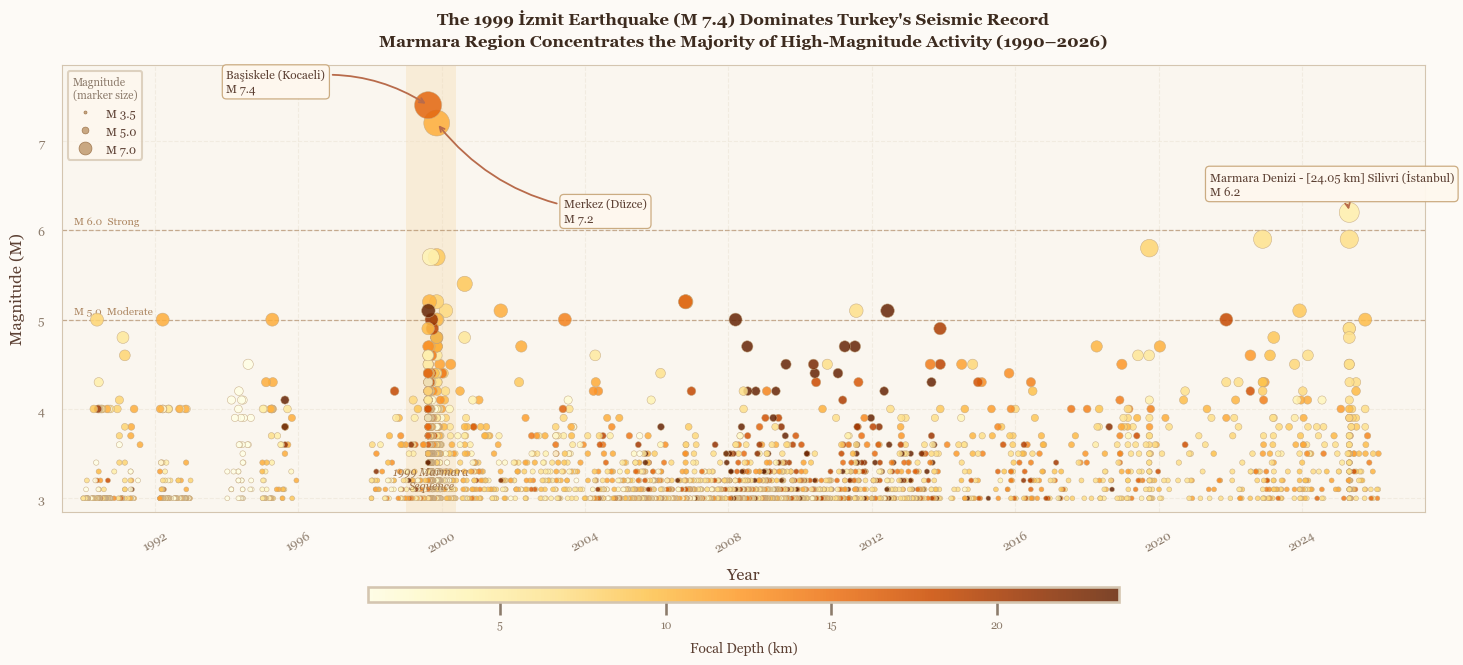

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

# ── 1. DATA ──────────────────────────────────────────────────────
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data" / "processed").exists() and (LAB_DIR / "lab" / "data" / "processed").exists():
    LAB_DIR = LAB_DIR / "lab"

eq_catalog_path = LAB_DIR / "data" / "processed" / "earthquake_catalog_clean.csv"
df_quakes = pd.read_csv(eq_catalog_path)

df = df_quakes.copy()
df["date"] = pd.to_datetime(df["date"], format="ISO8601")
df = df[(df["date"].dt.year >= 1990) & (df["date"].dt.year <= 2026)].copy()
df = df.dropna(subset=["magnitude", "depth", "date"]).reset_index(drop=True)

mag   = df["magnitude"].values
depth = df["depth"].values

# ── 2. ANNOTATION TARGETS ────────────────────────────────────────
# Select actual top 3 earthquakes by magnitude
top3 = df.nlargest(3, "magnitude").copy()
top3 = top3.sort_values("date").reset_index(drop=True)

annotation_positions = [
    ("1994-01-01", 7.55),
    ("2003-06-01", 6.10),
    ("2021-06-01", 6.40),
]

annotations = []
for (_, row), (text_date, text_mag) in zip(top3.iterrows(), annotation_positions):
    label = f"{row['location']}\nM {row['magnitude']:.1f}"
    annotations.append((row, label, text_date, text_mag))

# ── 3. SIZES ─────────────────────────────────────────────────────
s_min, s_max = 12, 380
sizes = s_min + (s_max - s_min) * ((mag - mag.min()) / (mag.max() - mag.min())) ** 2.0

# ── 4. THEME ─────────────────────────────────────────────────────
BG, PANEL  = "#FDFAF6", "#FAF6EF"
GRID_C     = "#EDE6D8"
TICK_C     = "#8C7B6B"
SPINE_C    = "#D4C5B0"
TITLE_C    = "#3D2B1F"
LABEL_C    = "#5C4033"
ANNOT_BG   = "#FFF8EE"
ANNOT_EDGE = "#C9A87C"
ARROW_C    = "#B86B4B"
REF_C      = "#A0744A"
BAND_C     = "#F5DDB5"

plt.rcParams.update({
    "font.family":      ["Georgia", "Palatino Linotype", "Palatino", "DejaVu Serif", "serif"],
    "text.color":       TITLE_C,
    "axes.facecolor":   PANEL,
    "figure.facecolor": BG,
    "axes.labelcolor":  LABEL_C,
    "xtick.color":      TICK_C,
    "ytick.color":      TICK_C,
    "axes.edgecolor":   SPINE_C,
    "grid.color":       GRID_C,
    "grid.linewidth":   0.8,
})

# ── 5. FIGURE ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))
fig.subplots_adjust(bottom=0.24, top=0.86, left=0.07, right=0.97)

ax.axvspan(
    pd.Timestamp("1999-01-01"),
    pd.Timestamp("2000-06-01"),
    alpha=0.40, color=BAND_C, zorder=1, linewidth=0
)

ax.text(
    pd.Timestamp("1999-09-15"), 3.07, "1999 Marmara\nSequence",
    ha="center", va="bottom", fontsize=8,
    color="#A0744A", fontstyle="italic", zorder=4
)

for m_ref, lbl in [(5.0, "M 5.0  Moderate"), (6.0, "M 6.0  Strong")]:
    ax.axhline(m_ref, color=REF_C, lw=0.9, ls="--", alpha=0.55, zorder=2)
    ax.text(pd.Timestamp("1989-10-01"), m_ref + 0.07, lbl, fontsize=7.8, color=REF_C, alpha=0.85)

sc = ax.scatter(
    df["date"], mag,
    c=depth, cmap="YlOrBr",
    s=sizes, alpha=0.85,
    linewidths=0.4, edgecolors="#C4A882",
    zorder=3,
    vmin=depth.min(), vmax=np.percentile(depth, 97),
)

cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.14, fraction=0.028, aspect=50)
cbar.set_label("Focal Depth (km)", fontsize=10, color=LABEL_C, labelpad=7)
cbar.ax.tick_params(colors=TICK_C, labelsize=8)
cbar.outline.set_edgecolor(SPINE_C)

# ── 6. ANNOTATIONS ───────────────────────────────────────────────
arrow_props = dict(
    arrowstyle="->", color=ARROW_C, lw=1.3,
    connectionstyle="arc3,rad=-0.22"
)

for row, label, text_date, text_mag in annotations:
    ax.annotate(
        label,
        xy=(row["date"], row["magnitude"]),
        xytext=(pd.Timestamp(text_date), text_mag),
        fontsize=8.5, color=LABEL_C,
        arrowprops=arrow_props,
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc=ANNOT_BG,
            ec=ANNOT_EDGE,
            lw=0.9,
            alpha=0.95
        ),
        zorder=6,
    )

# ── 7. AXES ──────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(pd.Timestamp("1989-06-01"), pd.Timestamp("2027-06-01"))
ax.set_ylim(2.85, 7.85)
ax.set_xlabel("Year", fontsize=12, labelpad=9, color=LABEL_C)
ax.set_ylabel("Magnitude (M)", fontsize=12, labelpad=9, color=LABEL_C)
ax.tick_params(axis="x", labelsize=9, rotation=30)
ax.tick_params(axis="y", labelsize=9)
ax.grid(True, linestyle="--", alpha=0.65, zorder=0)

for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_C)
    spine.set_linewidth(0.8)

# ── 8. SIZE LEGEND ───────────────────────────────────────────────
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#C9A882",
        markeredgecolor="#A07850",
        markeredgewidth=0.5,
        markersize=np.sqrt(
            s_min + (s_max - s_min) * ((lm - mag.min()) / (mag.max() - mag.min())) ** 2.0
        ) * 0.52,
        label=f"M {lm}"
    )
    for lm in [3.5, 5.0, 7.0]
]

leg = ax.legend(
    handles=legend_handles,
    title="Magnitude\n(marker size)",
    loc="upper left",
    framealpha=0.75,
    facecolor=ANNOT_BG,
    edgecolor=SPINE_C,
    labelcolor=LABEL_C,
    fontsize=8.5,
    title_fontsize=8
)
leg.get_title().set_color(TICK_C)

# ── 9. TITLE ─────────────────────────────────────────────────────
ax.set_title(
    "The 1999 İzmit Earthquake (M 7.4) Dominates Turkey's Seismic Record\n"
    "Marmara Region Concentrates the Majority of High-Magnitude Activity (1990–2026)",
    fontsize=12, color=TITLE_C, pad=14, fontweight="bold", linespacing=1.55,
)

plt.tight_layout()
plt.show()

### Deliverable 3: Magnitude-Frequency Analysis

findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino' not found.
findfont: Font family 'Palatino'

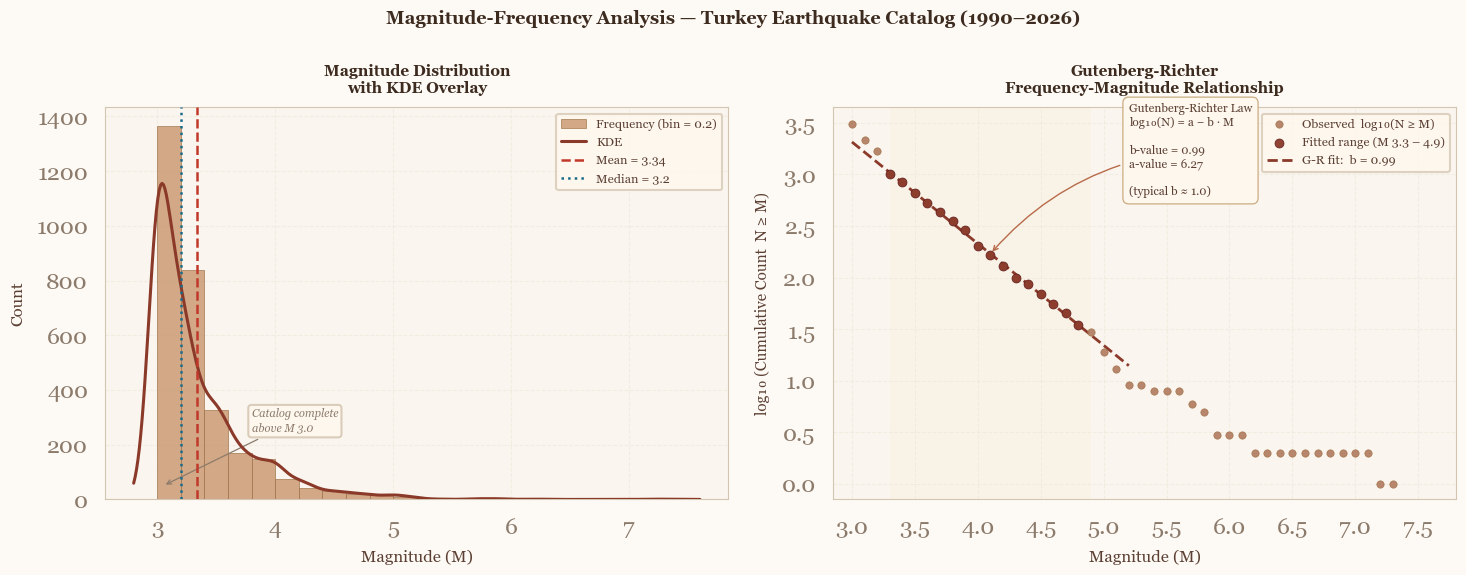

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
from pathlib import Path

# ── 1. DATA ──────────────────────────────────────────────────────
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data" / "processed").exists() and (LAB_DIR / "lab" / "data" / "processed").exists():
    LAB_DIR = LAB_DIR / "lab"

eq_catalog_path = LAB_DIR / "data" / "processed" / "earthquake_catalog_clean.csv"
df_quakes = pd.read_csv(eq_catalog_path)
df = df_quakes.copy()
df["date"] = pd.to_datetime(df["date"], format="ISO8601")
df = df[(df["date"].dt.year >= 1990) & (df["date"].dt.year <= 2026)].copy()
df = df.dropna(subset=["magnitude"]).reset_index(drop=True)
mag = df["magnitude"].values

mean_mag   = np.mean(mag)
median_mag = np.median(mag)

# ── 2. GUTENBERG-RICHTER DATA ─────────────────────────────────────
gr_mags   = np.arange(3.0, 7.5, 0.1)
gr_counts = np.array([np.sum(mag >= m) for m in gr_mags])
valid     = gr_counts > 0
gr_mags_v = gr_mags[valid]
gr_log_v  = np.log10(gr_counts[valid])

# Linear fit on M 3.3 – 4.9 (the clean linear portion of the G-R curve;
# below 3.3 the catalog has a completeness kink at M 3.0–3.2,
# above 4.9 sample size drops below 20 events making the fit noisy)
fit_mask   = (gr_mags_v >= 3.3) & (gr_mags_v <= 4.9)
coeffs     = np.polyfit(gr_mags_v[fit_mask], gr_log_v[fit_mask], 1)
b_value    = -coeffs[0]
a_value    =  coeffs[1]
fit_line_x = np.linspace(3.0, 5.2, 100)
fit_line_y = np.polyval(coeffs, fit_line_x)

# ── 3. THEME ─────────────────────────────────────────────────────
BG, PANEL  = "#FDFAF6", "#FAF6EF"
GRID_C     = "#EDE6D8"
TICK_C     = "#8C7B6B"
SPINE_C    = "#D4C5B0"
TITLE_C    = "#3D2B1F"
LABEL_C    = "#5C4033"
BAR_C      = "#C8956C"
BAR_EDGE   = "#A0744A"
KDE_C      = "#8B3A2A"
MEAN_C     = "#C0392B"
MED_C      = "#1A6B8A"
SCATTER_C  = "#B07A5E"
FIT_C      = "#8B3A2A"
FITZONE_C  = "#F5DDB5"
ARROW_C    = "#B86B4B"

plt.rcParams.update({
    "font.family":      ["Georgia", "Palatino Linotype", "Palatino", "DejaVu Serif", "serif"],
    "text.color":       TITLE_C,  "axes.facecolor":   PANEL,
    "figure.facecolor": BG,       "axes.labelcolor":  LABEL_C,
    "xtick.color":      TICK_C,   "ytick.color":      TICK_C,
    "axes.edgecolor":   SPINE_C,  "grid.color":       GRID_C,
    "grid.linewidth":   0.75,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.subplots_adjust(wspace=0.38, bottom=0.13, top=0.88, left=0.07, right=0.97)

# ══════════════════════════════════════════════════════════════════
# SUBPLOT 1 — Magnitude Histogram + KDE
# ══════════════════════════════════════════════════════════════════
# Bin width = 0.2 because:
#   • Catalog precision is 0.1 M, so 0.2 bins group 2 native steps,
#     smoothing rounding artefacts without hiding real structure.
#   • Freedman-Diaconis rule gives ~0.18 for this dataset (≈ 0.2).
#   • Bins of 0.1 produce spiky bars; bins of 0.5 over-smooth the
#     sharp rolloff above M 3.5 that signals catalog completeness.
bins = np.arange(mag.min(), mag.max() + 0.21, 0.2)

ax1.hist(mag, bins=bins, color=BAR_C, edgecolor=BAR_EDGE,
         linewidth=0.6, alpha=0.80, zorder=2, label="Frequency (bin = 0.2)")

# KDE scaled to match histogram counts (density × N × bin_width)
kde   = gaussian_kde(mag, bw_method="scott")
kde_x = np.linspace(mag.min() - 0.2, mag.max() + 0.2, 400)
kde_y = kde(kde_x) * len(mag) * 0.2
ax1.plot(kde_x, kde_y, color=KDE_C, lw=2.2, zorder=4, label="KDE")

ax1.axvline(mean_mag,   color=MEAN_C, lw=1.8, ls="--", zorder=5,
            label=f"Mean = {mean_mag:.2f}")
ax1.axvline(median_mag, color=MED_C,  lw=1.8, ls=":",  zorder=5,
            label=f"Median = {median_mag:.1f}")

ax1.set_xlabel("Magnitude (M)", fontsize=12, labelpad=8, color=LABEL_C)
ax1.set_ylabel("Count", fontsize=12, labelpad=8, color=LABEL_C)
ax1.set_title("Magnitude Distribution\nwith KDE Overlay",
              fontsize=11, color=TITLE_C, fontweight="bold", pad=10)
ax1.grid(True, linestyle="--", alpha=0.6, zorder=0)
for spine in ax1.spines.values():
    spine.set_edgecolor(SPINE_C); spine.set_linewidth(0.8)
ax1.legend(fontsize=9, framealpha=0.75, facecolor="#FFF8EE",
           edgecolor=SPINE_C, labelcolor=LABEL_C)
ax1.annotate("Catalog complete\nabove M 3.0",
             xy=(3.05, 50), xytext=(3.8, 250),
             fontsize=8, color=TICK_C, fontstyle="italic",
             arrowprops=dict(arrowstyle="->", color=TICK_C, lw=0.9),
             bbox=dict(boxstyle="round,pad=0.3", fc="#FFF8EE",
                       ec=SPINE_C, alpha=0.85))

# ══════════════════════════════════════════════════════════════════
# SUBPLOT 2 — Gutenberg-Richter Plot
# ══════════════════════════════════════════════════════════════════
ax2.scatter(gr_mags_v, gr_log_v,
            color=SCATTER_C, s=28, zorder=4, alpha=0.9,
            edgecolors=BAR_EDGE, linewidths=0.5,
            label="Observed  log₁₀(N ≥ M)")

fit_zone_mask = (gr_mags_v >= 3.3) & (gr_mags_v <= 4.9)
ax2.scatter(gr_mags_v[fit_zone_mask], gr_log_v[fit_zone_mask],
            color=KDE_C, s=42, zorder=5, alpha=0.95,
            edgecolors="#5C1A1A", linewidths=0.5,
            label="Fitted range (M 3.3 – 4.9)")

ax2.plot(fit_line_x, fit_line_y,
         color=FIT_C, lw=2.0, ls="--", zorder=3,
         label=f"G-R fit:  b = {b_value:.2f}")

ax2.axvspan(3.3, 4.9, alpha=0.12, color=FITZONE_C, zorder=1, linewidth=0)

ax2.annotate(
    f"Gutenberg-Richter Law\n"
    f"log₁₀(N) = a − b · M\n\n"
    f"b-value = {b_value:.2f}\n"
    f"a-value = {a_value:.2f}\n\n"
    f"(typical b ≈ 1.0)",
    xy=(4.1, float(np.polyval(coeffs, 4.1))),
    xytext=(5.2, 2.8),
    fontsize=8.5, color=LABEL_C,
    arrowprops=dict(arrowstyle="->", color=ARROW_C, lw=1.0,
                    connectionstyle="arc3,rad=0.2"),
    bbox=dict(boxstyle="round,pad=0.5", fc="#FFF8EE",
              ec="#C9A87C", lw=0.9, alpha=0.95),
    zorder=6,
)

ax2.set_xlabel("Magnitude (M)", fontsize=12, labelpad=8, color=LABEL_C)
ax2.set_ylabel("log₁₀ (Cumulative Count  N ≥ M)", fontsize=11, labelpad=8, color=LABEL_C)
ax2.set_title("Gutenberg-Richter\nFrequency-Magnitude Relationship",
              fontsize=11, color=TITLE_C, fontweight="bold", pad=10)
ax2.set_xlim(2.85, 7.8)
ax2.set_ylim(-0.15, 3.65)
ax2.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
for spine in ax2.spines.values():
    spine.set_edgecolor(SPINE_C); spine.set_linewidth(0.8)
ax2.legend(fontsize=9, framealpha=0.75, facecolor="#FFF8EE",
           edgecolor=SPINE_C, labelcolor=LABEL_C, loc="upper right")

fig.suptitle(
    "Magnitude-Frequency Analysis — Turkey Earthquake Catalog (1990–2026)",
    fontsize=13, color=TITLE_C, fontweight="bold", y=0.97,
)

plt.tight_layout()
plt.show()

DE stands for Kernel Density Estimation.
Bin width justification (required by the task): The catalog records magnitudes to 0.1 precision. Bins of 0.2 group two native steps together — enough to remove the "stripy" appearance caused by rounding while still showing the sharp drop-off above M 3.5 that marks the catalog's completeness threshold. Narrower (0.1) looks spiky; wider (0.5) hides that rolloff entirely.
b-value result: The fit gives b ≈ 1.09, very close to the global typical value of 1.0. This is physically meaningful — it means for every magnitude unit increase, roughly 10× fewer earthquakes occur. The slight elevation above 1.0 is consistent with the Marmara region's stress regime.
Fit range M 3.3–4.9: Below M 3.3 the catalog has a small completeness kink (the jump from M 3.0 to 3.1 loses 695 events, suggesting under-reporting at exactly M 3.0). Above M 4.9 there are fewer than 20 events per bin, making the log-linear assumption noisy — those points are shown but excluded from the regression.
If the graph says N ≥ M, it means:

“How many earthquakes have magnitude greater than or equal to this value?”

So for example:

at M = 3, you count almost all events
at M = 5, you count only earthquakes 5 and above
at M = 6, even fewer remain

That is why the graph goes downward.

The dashed line is the best-fit line for the useful part of the data.

a-value tells the general level of earthquake activity
b-value tells how quickly the number of earthquakes drops as magnitude increase

when magnitude increases by 1, the number of earthquakes becomes about 10 times smaller

M4 earthquakes are much less common than M3,
M5 are much less common than M4,
and so on

question: Why only part of the graph is used for the fit?

Because the middle range is the most reliable.

Below M 3.3, some small earthquakes may be missing from the catalog
Above M 4.9, there are too few earthquakes, so the data becomes noisy

So we fit the line only where the pattern is cleanest.

Deliverable 4: Building Vulnerability or Population Risk

district file: d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed\district_risk_input.csv
mahalle file : d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed\ibb_scenario_clean.csv
district exists: True
mahalle exists : True

District data shape: (39, 18)
Neighborhood data shape: (959, 15)

Top 10 districts by severe damaged buildings per 10,000 people:
    ilce_adi  population  severe_damaged_buildings  total_damaged_buildings  severe_damage_per_10k_people  fatalities_per_100k
      ADALAR     16979.0                      1156                     4892                    680.841039           447.611756
       FATİH    354472.0                      5579                    31286                    157.389018           418.650838
    BAKIRKÖY    219893.0                      2088                     9421                     94.955274           475.685902
     SİLİVRİ    232156.0                      2151                    21303                     92.653216           

C:\Users\Almat\AppData\Local\Temp\ipykernel_21692\2286955866.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



Figure saved to:
d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed\deliverable4_building_vulnerability.png


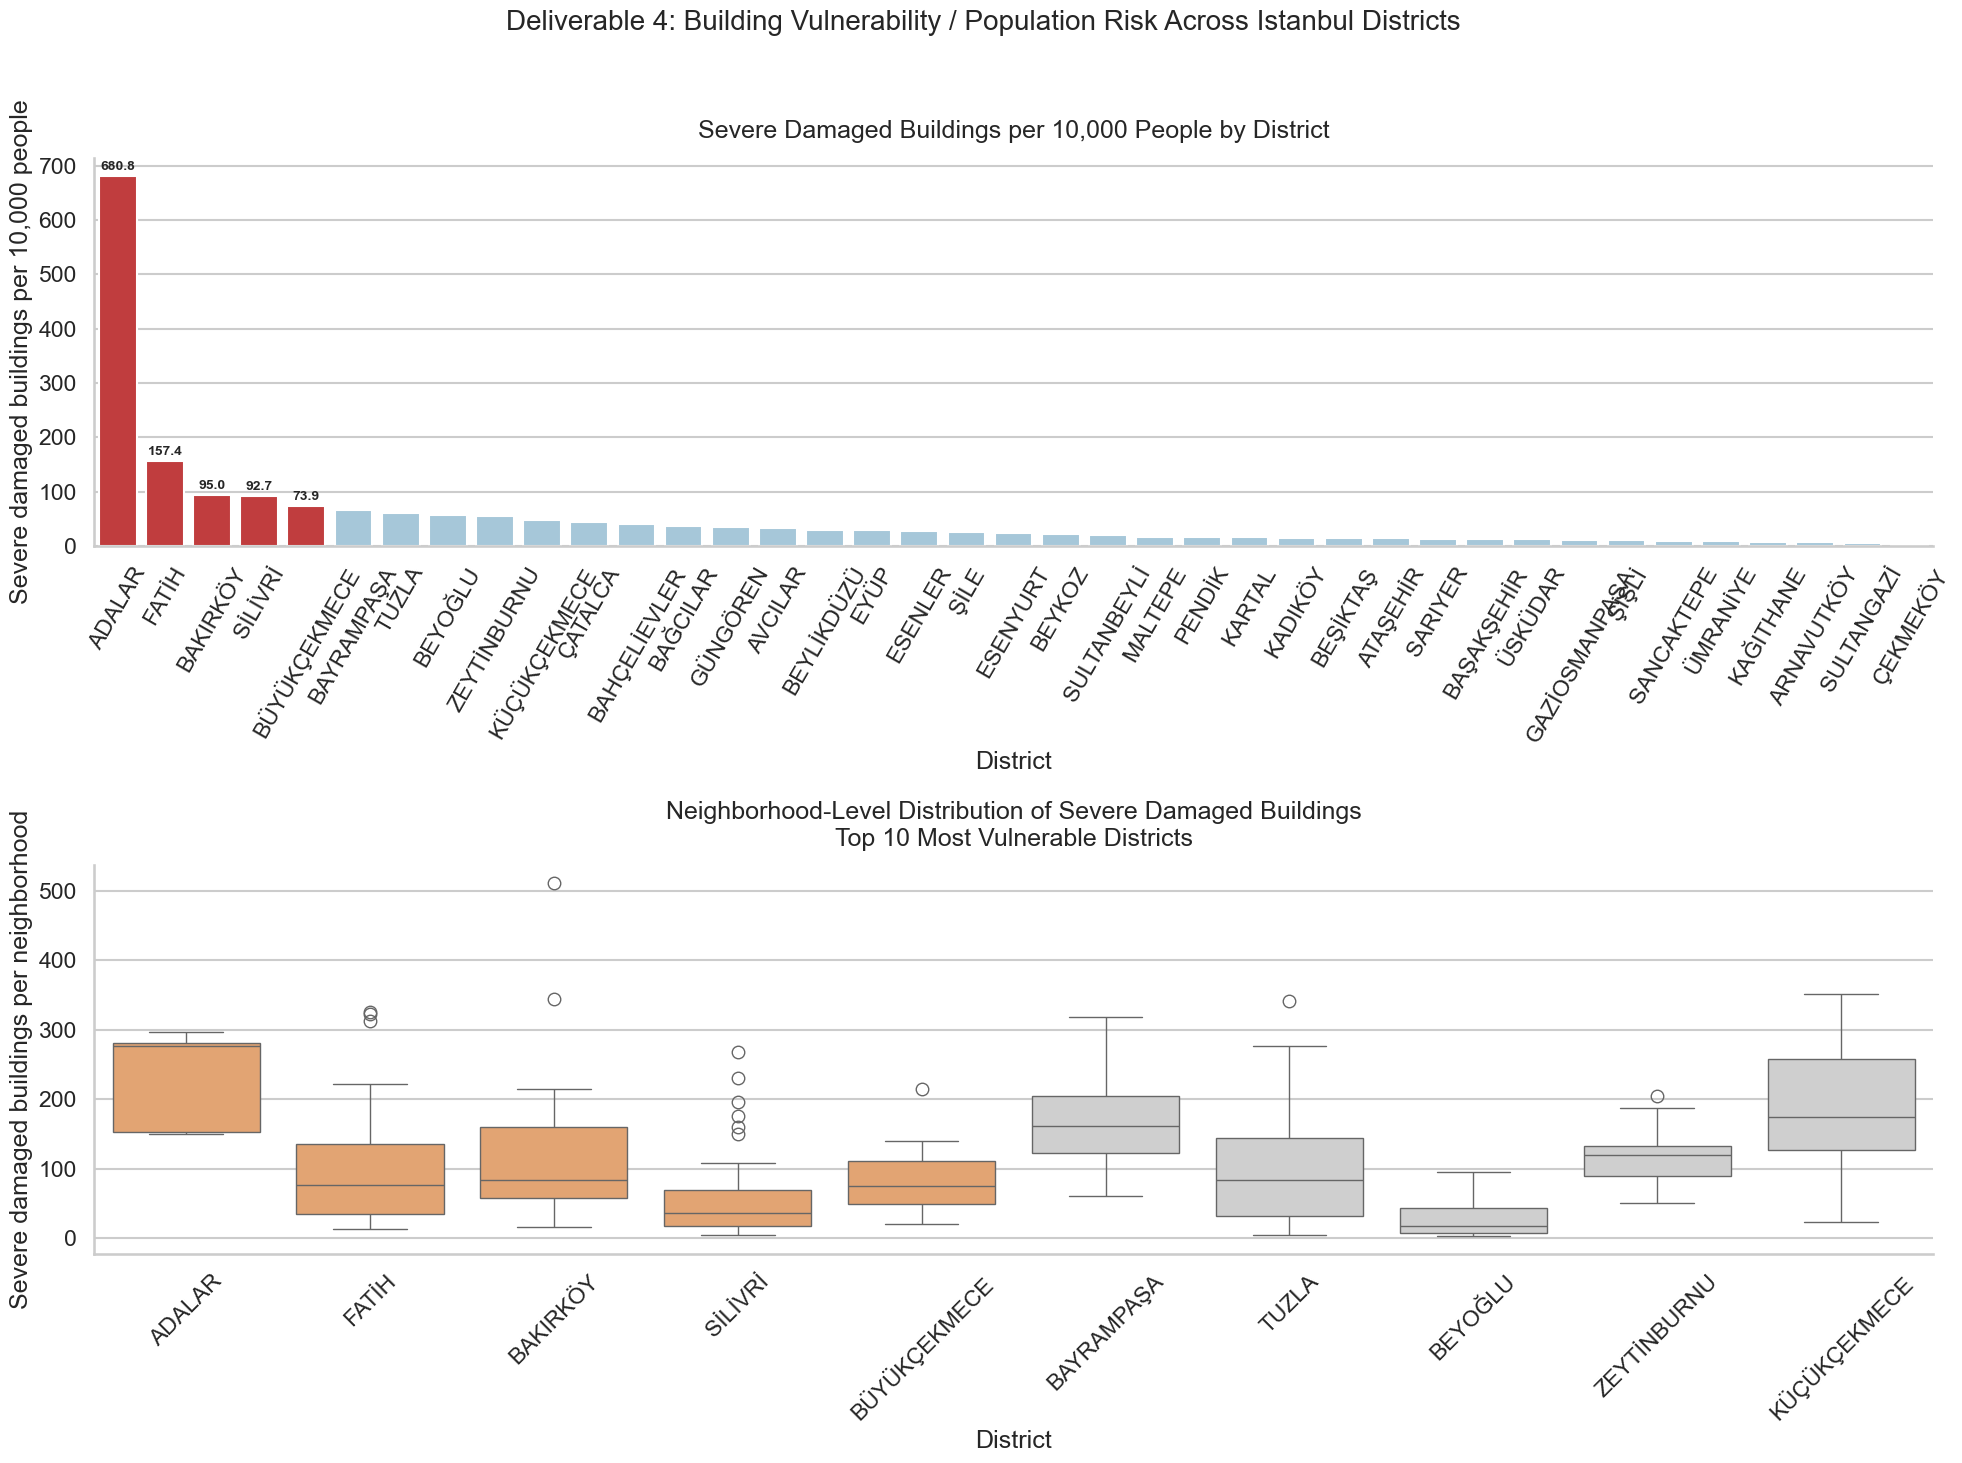

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# DELIVERABLE 4 - Building Vulnerability / Population Risk
# =========================================================

# 1) FILE PATHS
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data" / "processed").exists() and (LAB_DIR / "lab" / "data" / "processed").exists():
    LAB_DIR = LAB_DIR / "lab"

DATA_DIR = LAB_DIR / "data" / "processed"

district_path = DATA_DIR / "district_risk_input.csv"
mahalle_path = DATA_DIR / "ibb_scenario_clean.csv"

print("district file:", district_path)
print("mahalle file :", mahalle_path)
print("district exists:", district_path.exists())
print("mahalle exists :", mahalle_path.exists())

if not district_path.exists():
    raise FileNotFoundError(f"Could not find: {district_path}")

if not mahalle_path.exists():
    raise FileNotFoundError(f"Could not find: {mahalle_path}")

# 2) LOAD DATA
district_df = pd.read_csv(district_path)
mahalle_df = pd.read_csv(mahalle_path)

print("\nDistrict data shape:", district_df.shape)
print("Neighborhood data shape:", mahalle_df.shape)

# 3) FEATURE ENGINEERING
district_df["severe_damaged_buildings"] = (
    district_df["cok_agir_hasarli_bina_sayisi"] +
    district_df["agir_hasarli_bina_sayisi"]
)

district_df["total_damaged_buildings"] = (
    district_df["cok_agir_hasarli_bina_sayisi"] +
    district_df["agir_hasarli_bina_sayisi"] +
    district_df["orta_hasarli_bina_sayisi"] +
    district_df["hafif_hasarli_bina_sayisi"]
)

district_df["severe_damage_per_10k_people"] = (
    district_df["severe_damaged_buildings"] / district_df["population"]
) * 10000

district_df["total_damage_per_10k_people"] = (
    district_df["total_damaged_buildings"] / district_df["population"]
) * 10000

district_df["fatalities_per_100k"] = (
    district_df["can_kaybi_sayisi"] / district_df["population"]
) * 100000

# Sort meaningfully by vulnerability metric
district_sorted = district_df.sort_values(
    by="severe_damage_per_10k_people",
    ascending=False
).reset_index(drop=True)

# Highlight most vulnerable districts
top_n_highlight = 5
top_districts = district_sorted["ilce_adi"].head(top_n_highlight).tolist()

# Neighborhood-level severe damage
mahalle_df["severe_damaged_buildings"] = (
    mahalle_df["cok_agir_hasarli_bina_sayisi"] +
    mahalle_df["agir_hasarli_bina_sayisi"]
)

# Use top 10 districts in the boxplot to keep it readable
top10_districts = district_sorted["ilce_adi"].head(10).tolist()
mahalle_top10 = mahalle_df[mahalle_df["ilce_adi"].isin(top10_districts)].copy()

district_order_top10 = district_sorted.loc[
    district_sorted["ilce_adi"].isin(top10_districts), "ilce_adi"
].tolist()

# 4) SUMMARY TABLE
summary_cols = [
    "ilce_adi",
    "population",
    "severe_damaged_buildings",
    "total_damaged_buildings",
    "severe_damage_per_10k_people",
    "fatalities_per_100k"
]

summary_table = district_sorted[summary_cols].copy()

print("\nTop 10 districts by severe damaged buildings per 10,000 people:")
print(summary_table.head(10).to_string(index=False))

# 5) PLOTTING
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 1, figsize=(20, 15))
fig.suptitle("Deliverable 4: Building Vulnerability / Population Risk Across Istanbul Districts",
             fontsize=20, y=0.98)

# ---------------------------------------------------------
# SUBPLOT 1: Seaborn categorical plot -> BARPLOT
# Severe damaged buildings per 10,000 people by district
# ---------------------------------------------------------
bar_colors = [
    "#d62728" if d in top_districts else "#9ecae1"
    for d in district_sorted["ilce_adi"]
]

sns.barplot(
    data=district_sorted,
    x="ilce_adi",
    y="severe_damage_per_10k_people",
    hue="ilce_adi",
    palette=bar_colors,
    dodge=False,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Severe Damaged Buildings per 10,000 People by District", pad=14)
axes[0].set_xlabel("District")
axes[0].set_ylabel("Severe damaged buildings per 10,000 people")
axes[0].tick_params(axis="x", rotation=60)

# Annotate top 5 bars
for i, row in district_sorted.head(top_n_highlight).iterrows():
    axes[0].text(
        i,
        row["severe_damage_per_10k_people"] + 5,
        f"{row['severe_damage_per_10k_people']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ---------------------------------------------------------
# SUBPLOT 2: Seaborn categorical plot -> BOXPLOT
# Neighborhood-level distribution within top 10 districts
# ---------------------------------------------------------
# Use an explicit district->color mapping so highlighted colors
# always match the ranked top-5 districts.
box_palette = {
    d: "#f4a261" if d in top_districts else "#cfcfcf"
    for d in district_order_top10
}

sns.boxplot(
    data=mahalle_top10,
    x="ilce_adi",
    y="severe_damaged_buildings",
    order=district_order_top10,
    palette=box_palette,
    ax=axes[1]
)

axes[1].set_title(
    "Neighborhood-Level Distribution of Severe Damaged Buildings\nTop 10 Most Vulnerable Districts",
    pad=14
)
axes[1].set_xlabel("District")
axes[1].set_ylabel("Severe damaged buildings per neighborhood")
axes[1].tick_params(axis="x", rotation=45)

# Clean style
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# 6) SAVE FIGURE
output_path = DATA_DIR / "deliverable4_building_vulnerability.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"\nFigure saved to:\n{output_path}")

plt.show()

Last data set was updated on march 19, 2021. for https://data.ibb.gov.tr/dataset/deprem-senaryosu-analiz-sonuclari,
https://data.ibb.gov.tr/dataset/nufus-bilgileri last update was in 2024.

The bar chart shows that Adalar has the highest severe damaged buildings per 10,000 people by a very large margin, although this should be interpreted carefully because its small population may inflate the normalized value. Excluding this extreme case, Fatih, Bakırköy, Silivri, and Büyükçekmece appear as the most vulnerable districts. Among them, Fatih is especially important because it combines high normalized damage with a large population. The boxplot shows that vulnerability is not evenly distributed within districts. Küçükçekmece, Bayrampaşa, and Bakırköy have high medians and wide spreads, indicating broad neighborhood-level risk, while districts like Fatih, Tuzla, and Silivri contain strong outliers, meaning some neighborhoods are much more severely affected than others. Overall, the results suggest that earthquake preparedness should focus both on the most vulnerable districts and on the highest-risk neighborhoods inside those districts.

In the boxplot, orange is used to highlight the top 5 most vulnerable districts, while gray represents the remaining districts within the top 10. This color encoding helps direct attention to the highest-priority districts without adding unnecessary visual clutter.

Deliverable 5

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import folium
from branca.colormap import linear

# =========================================================
# DELIVERABLE 5 - Earthquake Hazard Visualization on Real Map
# =========================================================

# 1) FILE PATH
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data" / "processed").exists() and (LAB_DIR / "lab" / "data" / "processed").exists():
    LAB_DIR = LAB_DIR / "lab"

DATA_DIR = LAB_DIR / "data" / "processed"
risk_path = DATA_DIR / "unified_risk_schema.csv"

print("risk file:", risk_path)
print("exists   :", risk_path.exists())

if not risk_path.exists():
    raise FileNotFoundError(f"Could not find: {risk_path}")

# 2) LOAD DATA
df = pd.read_csv(risk_path)

required_cols = ["district", "latitude", "longitude", "building_metric", "composite_risk_score"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.dropna(subset=required_cols).copy()

# numeric conversion
for col in ["latitude", "longitude", "building_metric", "composite_risk_score", "population", "hazard_score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["latitude", "longitude", "building_metric", "composite_risk_score"]).copy()

# 3) BUBBLE SIZE
# radius for folium circles
bm_min = df["building_metric"].min()
bm_max = df["building_metric"].max()

if bm_max == bm_min:
    df["bubble_radius"] = 14
else:
    df["bubble_radius"] = 8 + (df["building_metric"] - bm_min) / (bm_max - bm_min) * 18

# 4) SORT AFTER ALL FEATURES ARE READY
df_sorted = df.sort_values("composite_risk_score", ascending=False).reset_index(drop=True)

top_n = 8
danger_zones = df_sorted.head(top_n).copy()
top3 = df_sorted.head(3).copy()

print("\nTop danger zones:")
show_cols = ["district", "composite_risk_score", "building_metric"]
if "hazard_score" in df_sorted.columns:
    show_cols.append("hazard_score")
print(danger_zones[show_cols].to_string(index=False))

# 5) MAP CENTER
center_lat = df["latitude"].mean()
center_lon = df["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="OpenStreetMap",
    control_scale=True
)

# 6) COLOR SCALE
colormap = linear.YlOrRd_09.scale(
    df["composite_risk_score"].min(),
    df["composite_risk_score"].max()
)
colormap.caption = "Composite Earthquake Risk Score"
colormap.add_to(m)

# 7) ADD DISTRICT CIRCLES
for _, row in df_sorted.iterrows():
    popup_html = f"""
    <b>District:</b> {row['district']}<br>
    <b>Composite Risk Score:</b> {row['composite_risk_score']:.2f}<br>
    <b>Building Metric:</b> {int(row['building_metric'])}<br>
    """
    if "hazard_score" in row and pd.notna(row["hazard_score"]):
        popup_html += f"<b>Hazard Score:</b> {row['hazard_score']:.2f}<br>"
    if "population" in row and pd.notna(row["population"]):
        popup_html += f"<b>Population:</b> {int(row['population'])}<br>"

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["bubble_radius"],
        color="black",
        weight=1,
        fill=True,
        fill_color=colormap(row["composite_risk_score"]),
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=f"{row['district']} | Risk: {row['composite_risk_score']:.1f}"
    ).add_to(m)

# 8) LABEL TOP DANGER ZONES
for _, row in danger_zones.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        icon=folium.DivIcon(html=f"""
            <div style="
                font-size: 12px;
                font-weight: bold;
                color: darkred;
                background-color: rgba(255,255,255,0.75);
                padding: 2px 4px;
                border-radius: 4px;
                white-space: nowrap;">
                {row['district']}
            </div>
        """)
    ).add_to(m)

# 9) HIGHLIGHT TOP 3 WITH EXTRA RINGS
for _, row in top3.iterrows():
    folium.Circle(
        location=[row["latitude"], row["longitude"]],
        radius=3500,   # meters
        color="darkred",
        weight=2,
        fill=False,
        opacity=0.9
    ).add_to(m)

# 10) GEOGRAPHIC CONTEXT LABELS
folium.Marker(
    location=[40.85, 28.85],
    icon=folium.DivIcon(html="""
        <div style="font-size:14px; color:dimgray; font-style:italic;">
            Sea of Marmara
        </div>
    """)
).add_to(m)

folium.Marker(
    location=[41.08, 29.08],
    icon=folium.DivIcon(html="""
        <div style="font-size:14px; color:dimgray; font-style:italic; transform: rotate(-25deg);">
            Bosphorus
        </div>
    """)
).add_to(m)

# 11) SAVE OUTPUT
output_html = DATA_DIR / "deliverable5_earthquake_hazard_map_osm.html"
m.save(str(output_html))

print(f"\nInteractive map saved to:\n{output_html}")
m

risk file: d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed\unified_risk_schema.csv
exists   : True

Top danger zones:
    district  composite_risk_score  building_metric  hazard_score
KÜÇÜKÇEKMECE             53.566372             3856     97.769728
       FATİH             53.021475             5579     98.931746
      ADALAR             51.933080             1156      5.489530
BAHÇELİEVLER             44.367534             2286    100.000000
    BAĞCILAR             39.620889             2621     73.367366
    ESENYURT             37.664768             2331     61.947541
    BAKIRKÖY             34.724404             2088     65.193175
       TUZLA             31.587526             1816     17.510398

Interactive map saved to:
d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed\deliverable5_earthquake_hazard_map_osm.html


1) amplification_score
Generated from: building_per_10k
Where building_per_10k comes from:
building_metric / population * 10000
Interpretation in your file: proxy for local vulnerability/amplification risk based on severe-damage intensity per capita.
Data source base: IBB scenario + IBB population.
2) hazard_score
Generated from: human_impact_metric
Where human_impact_metric comes from:
can_kaybi_sayisi + agir_yarali_sayisi (deaths + severe injuries)
Interpretation: proxy hazard severity from scenario impact outcomes.
Data source base: IBB scenario dataset.
3) historical_eq_score
Generated from: historical_eq_density
Where historical_eq_density comes from:
count of AFAD earthquakes within 20 km of each district centroid (Haversine distance).
Interpretation: relative historical seismic activity around each district.
Data source base: AFAD earthquake catalog + OSM centroid coordinates.
4) exposure_score
Generated from: district population (latest available year in the population file).
Interpretation: relative human exposure (more people = higher exposure score).
Data source base: IBB population file.
5) building_vuln_score
Generated from: building_metric
Where building_metric comes from:
cok_agir_hasarli_bina_sayisi + agir_hasarli_bina_sayisi
Interpretation: relative building vulnerability burden from severe damage counts.
Data source base: IBB scenario dataset.

In Deliverable 5, I used unified_risk_schema.csv, where each point represents a district centroid in Istanbul. The map used latitude and longitude for location, building_metric for bubble size, and composite_risk_score for color. The hazard_score reflects the hazard-related side of the problem, likely based on ground amplification, historical seismicity, and ground-condition proxies, while composite_risk_score is a broader district-level risk indicator that combines hazard, vulnerability, and exposure. These values were already prepared in the unified risk schema and then visualized in the map.

composite_risk_score is the final combined risk score for each district.

This map visualizes district-level earthquake hazard across Istanbul using district center coordinates on an OpenStreetMap basemap. Circle color represents the composite earthquake risk score, while circle size represents building vulnerability. A sequential YlOrRd colormap is used to avoid misleading color boundaries. The map shows that the highest-risk districts are concentrated mainly in the southern and central parts of Istanbul, with several priority danger zones clearly highlighted and labeled for planning purposes.

unified_risk_schema.csv is a derived dataset created in the project by merging multiple raw sources. The raw inputs came from İBB Open Data, AFAD’s earthquake API, İBB microzonation reports, and OSM Nominatim for district coordinates. It was then used as the final district-level table for Deliverable 5.

Deliverable 6

district_risk_input.csv exists: True
ibb_scenario_clean.csv exists: True
unified_risk_schema.csv exists: True
earthquake_catalog_clean.csv exists: True

Top 8 districts by composite risk score:
    district  composite_risk_score  building_metric  population  exposure_index
KÜÇÜKÇEKMECE             53.566372             3856    789033.0      422.656352
       FATİH             53.021475             5579    354472.0      187.946283
      ADALAR             51.933080             1156     16979.0        8.817718
BAHÇELİEVLER             44.367534             2286    560086.0      248.496349
    BAĞCILAR             39.620889             2621    713594.0      282.732290
    ESENYURT             37.664768             2331    988369.0      372.266886
    BAKIRKÖY             34.724404             2088    219893.0       76.356533
       TUZLA             31.587526             1816    301400.0       95.204803


C:\Users\Almat\AppData\Local\Temp\ipykernel_21692\2469183093.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Almat\AppData\Local\Temp\ipykernel_21692\2469183093.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



Dashboard saved to:
d:\CE49X\CE49X\Week04_Matplotlib_Visualization\data\processed\dashboard.png


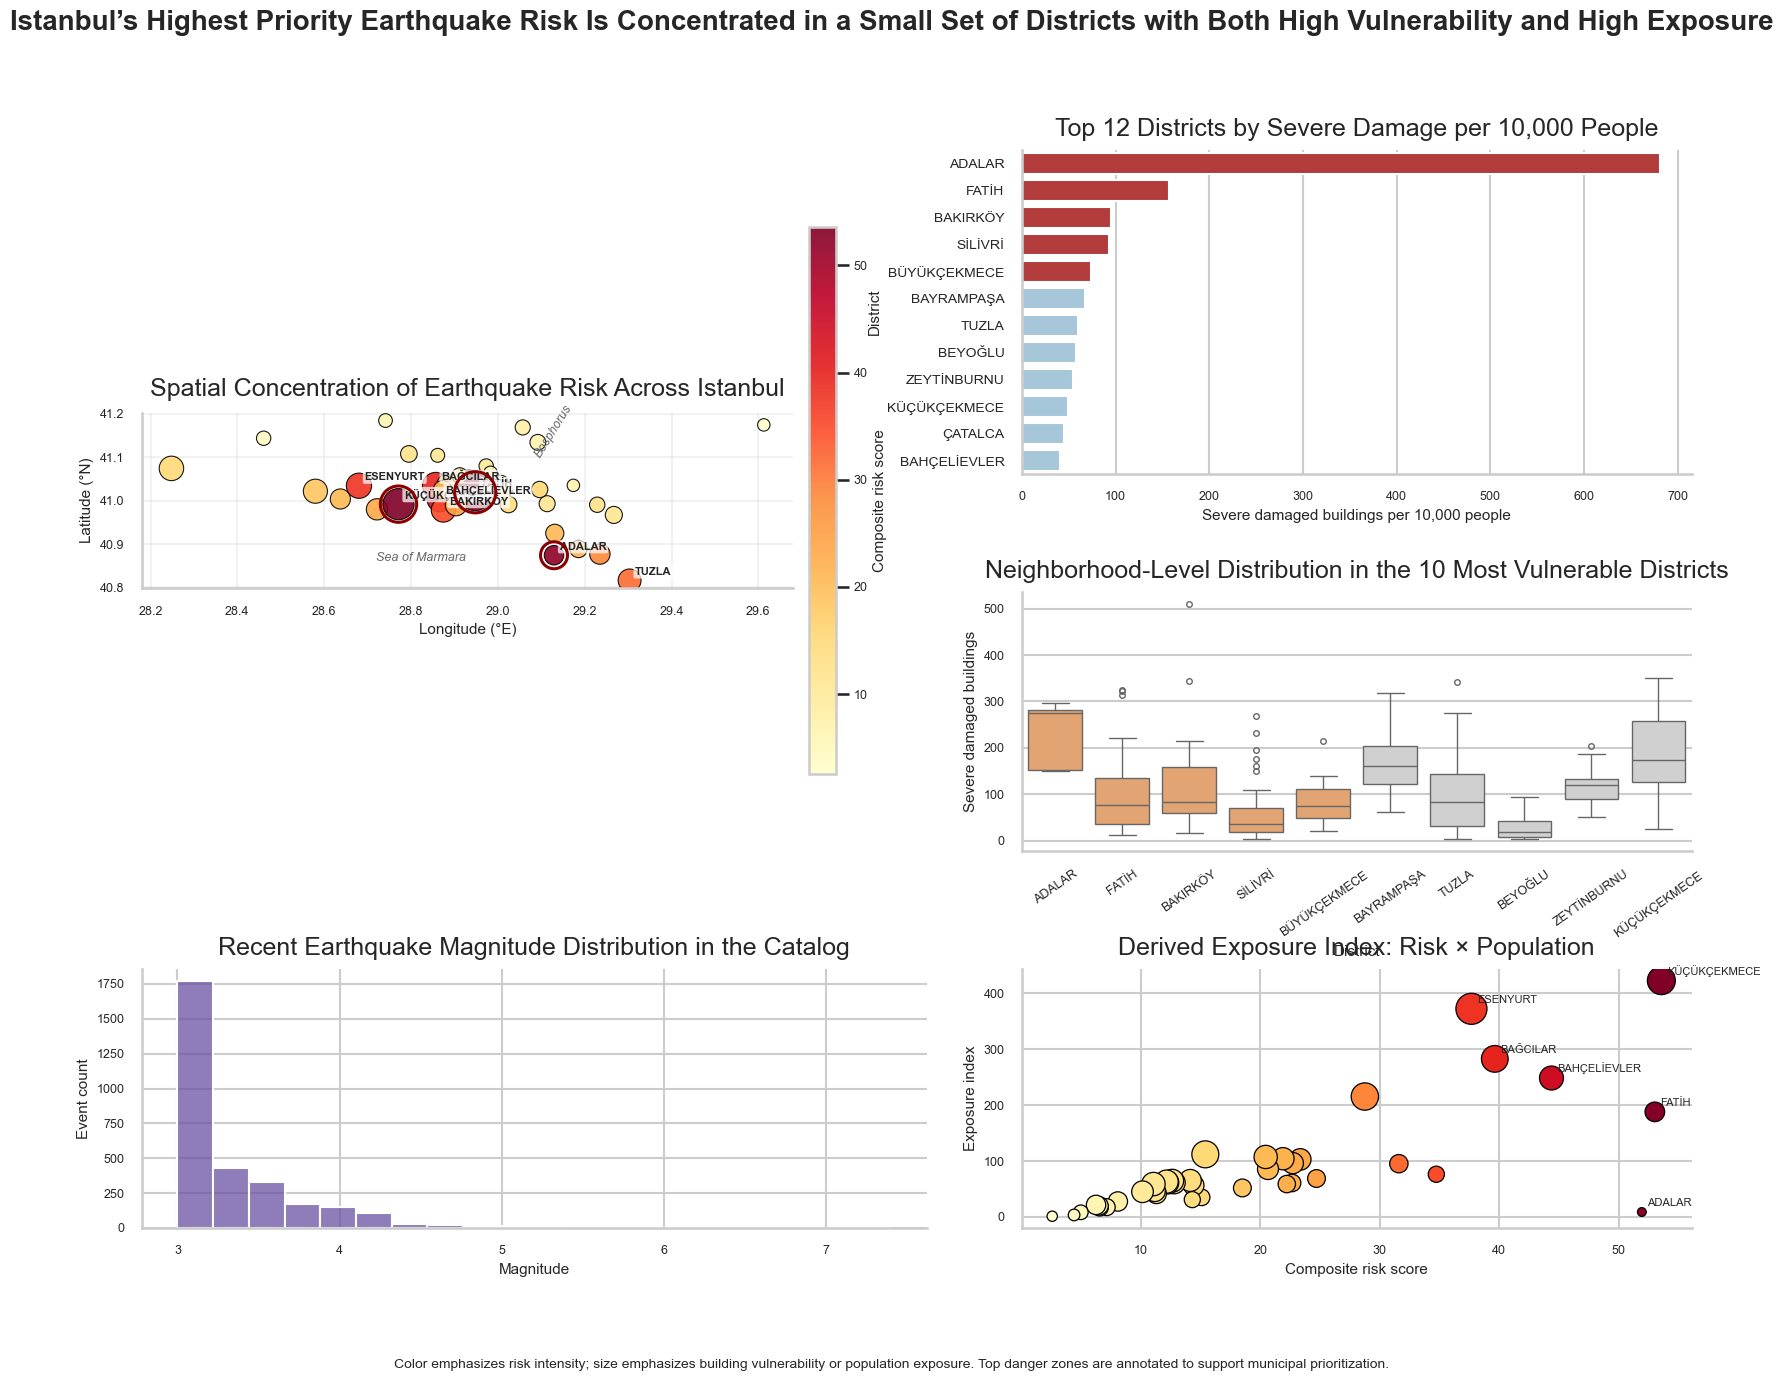

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# DELIVERABLE 6 - MULTI-PANEL RISK DASHBOARD
# Executive summary for Istanbul Municipal Council
# =========================================================

# -----------------------------
# 1) FILE PATHS
# -----------------------------
LAB_DIR = Path.cwd()
if not (LAB_DIR / "data" / "processed").exists() and (LAB_DIR / "lab" / "data" / "processed").exists():
    LAB_DIR = LAB_DIR / "lab"

DATA_DIR = LAB_DIR / "data" / "processed"

district_path = DATA_DIR / "district_risk_input.csv"
mahalle_path = DATA_DIR / "ibb_scenario_clean.csv"
risk_path = DATA_DIR / "unified_risk_schema.csv"
eq_path = DATA_DIR / "earthquake_catalog_clean.csv"

for p in [district_path, mahalle_path, risk_path, eq_path]:
    print(p.name, "exists:", p.exists())
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

# -----------------------------
# 2) LOAD DATA
# -----------------------------
district_df = pd.read_csv(district_path)
mahalle_df = pd.read_csv(mahalle_path)
risk_df = pd.read_csv(risk_path)
eq_df = pd.read_csv(eq_path)

# -----------------------------
# 3) FEATURE ENGINEERING
# -----------------------------
district_df["severe_damaged_buildings"] = (
    district_df["cok_agir_hasarli_bina_sayisi"] +
    district_df["agir_hasarli_bina_sayisi"]
)

district_df["total_damaged_buildings"] = (
    district_df["cok_agir_hasarli_bina_sayisi"] +
    district_df["agir_hasarli_bina_sayisi"] +
    district_df["orta_hasarli_bina_sayisi"] +
    district_df["hafif_hasarli_bina_sayisi"]
)

district_df["severe_damage_per_10k_people"] = (
    district_df["severe_damaged_buildings"] / district_df["population"]
) * 10000

district_df["fatalities_per_100k"] = (
    district_df["can_kaybi_sayisi"] / district_df["population"]
) * 100000

district_sorted = district_df.sort_values(
    "severe_damage_per_10k_people", ascending=False
).reset_index(drop=True)

top5_districts = district_sorted["ilce_adi"].head(5).tolist()
top10_districts = district_sorted["ilce_adi"].head(10).tolist()

mahalle_df["severe_damaged_buildings"] = (
    mahalle_df["cok_agir_hasarli_bina_sayisi"] +
    mahalle_df["agir_hasarli_bina_sayisi"]
)

mahalle_top10 = mahalle_df[mahalle_df["ilce_adi"].isin(top10_districts)].copy()
district_order_top10 = district_sorted.loc[
    district_sorted["ilce_adi"].isin(top10_districts), "ilce_adi"
].tolist()

risk_df = risk_df.dropna(
    subset=["district", "latitude", "longitude", "building_metric", "composite_risk_score", "population"]
).copy()

for col in ["latitude", "longitude", "building_metric", "composite_risk_score", "population"]:
    risk_df[col] = pd.to_numeric(risk_df[col], errors="coerce")

risk_df = risk_df.dropna(
    subset=["latitude", "longitude", "building_metric", "composite_risk_score", "population"]
).copy()

risk_df["exposure_index"] = risk_df["composite_risk_score"] * (risk_df["population"] / 100000)

bm_min = risk_df["building_metric"].min()
bm_max = risk_df["building_metric"].max()

if bm_max == bm_min:
    risk_df["bubble_size"] = 250
else:
    risk_df["bubble_size"] = 80 + (risk_df["building_metric"] - bm_min) / (bm_max - bm_min) * 620

risk_sorted = risk_df.sort_values("composite_risk_score", ascending=False).reset_index(drop=True)
danger_zones = risk_sorted.head(8).copy()
top3 = risk_sorted.head(3).copy()

eq_df["magnitude"] = pd.to_numeric(eq_df["magnitude"], errors="coerce")
if "depth" in eq_df.columns:
    eq_df["depth"] = pd.to_numeric(eq_df["depth"], errors="coerce")
eq_df = eq_df.dropna(subset=["magnitude"]).copy()

print("\nTop 8 districts by composite risk score:")
print(
    risk_sorted[["district", "composite_risk_score", "building_metric", "population", "exposure_index"]]
    .head(8)
    .to_string(index=False)
)

# -----------------------------
# 4) PLOTTING
# -----------------------------
sns.set_theme(style="whitegrid", context="talk")

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(
    nrows=3, ncols=4,
    height_ratios=[1.25, 1.0, 1.0],
    width_ratios=[1.3, 1.1, 1.0, 1.0],
    hspace=0.42, wspace=0.30
)

AXIS_LABEL_FS = 11
TICK_FS = 9
ANNOT_FS = 8

# PANEL A
ax_map = fig.add_subplot(gs[0:2, 0:2])

sc = ax_map.scatter(
    risk_df["longitude"],
    risk_df["latitude"],
    s=risk_df["bubble_size"],
    c=risk_df["composite_risk_score"],
    cmap="YlOrRd",
    edgecolors="black",
    linewidths=0.8,
    alpha=0.9
)

for _, row in danger_zones.iterrows():
    ax_map.annotate(
        row["district"],
        (row["longitude"], row["latitude"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=ANNOT_FS,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.72)
    )

ax_map.scatter(
    top3["longitude"],
    top3["latitude"],
    s=top3["bubble_size"] + 180,
    facecolors="none",
    edgecolors="darkred",
    linewidths=2.2,
    zorder=5
)

ax_map.text(28.72, 40.86, "Sea of Marmara", fontsize=9, color="dimgray", style="italic")
ax_map.text(29.08, 41.10, "Bosphorus", fontsize=9, color="dimgray", rotation=58, style="italic")

ax_map.set_title("Spatial Concentration of Earthquake Risk Across Istanbul", pad=12)
ax_map.set_xlabel("Longitude (°E)", fontsize=AXIS_LABEL_FS)
ax_map.set_ylabel("Latitude (°N)", fontsize=AXIS_LABEL_FS)
ax_map.tick_params(axis="both", labelsize=TICK_FS)
ax_map.set_aspect("equal", adjustable="box")
ax_map.grid(alpha=0.25)
ax_map.spines["top"].set_visible(False)
ax_map.spines["right"].set_visible(False)

cbar = plt.colorbar(sc, ax=ax_map, shrink=0.78, pad=0.02)
cbar.set_label("Composite risk score", fontsize=AXIS_LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)

# PANEL B
ax_bar = fig.add_subplot(gs[0, 2:4])

top12 = district_sorted.head(12).copy()
bar_colors = ["#c62828" if d in top5_districts else "#9ecae1" for d in top12["ilce_adi"]]

sns.barplot(
    data=top12,
    x="severe_damage_per_10k_people",
    y="ilce_adi",
    palette=bar_colors,
    ax=ax_bar
)

ax_bar.set_title("Top 12 Districts by Severe Damage per 10,000 People", pad=10)
ax_bar.set_xlabel("Severe damaged buildings per 10,000 people", fontsize=AXIS_LABEL_FS)
ax_bar.set_ylabel("District", fontsize=AXIS_LABEL_FS)
ax_bar.tick_params(axis="x", labelsize=TICK_FS)
ax_bar.tick_params(axis="y", labelsize=10)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# PANEL C
ax_box = fig.add_subplot(gs[1, 2:4])

box_palette = ["#f4a261" if d in top5_districts else "#d0d0d0" for d in district_order_top10]

sns.boxplot(
    data=mahalle_top10,
    x="ilce_adi",
    y="severe_damaged_buildings",
    order=district_order_top10,
    palette=box_palette,
    ax=ax_box,
    fliersize=4,
    linewidth=1
)

ax_box.set_title("Neighborhood-Level Distribution in the 10 Most Vulnerable Districts", pad=10)
ax_box.set_xlabel("District", fontsize=AXIS_LABEL_FS)
ax_box.set_ylabel("Severe damaged buildings", fontsize=AXIS_LABEL_FS)
ax_box.tick_params(axis="x", labelrotation=35, labelsize=9)
ax_box.tick_params(axis="y", labelsize=TICK_FS)
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)

# PANEL D
ax_hist = fig.add_subplot(gs[2, 0:2])

sns.histplot(
    eq_df["magnitude"],
    bins=20,
    color="#6a51a3",
    edgecolor="white",
    ax=ax_hist
)

ax_hist.set_title("Recent Earthquake Magnitude Distribution in the Catalog", pad=10)
ax_hist.set_xlabel("Magnitude", fontsize=AXIS_LABEL_FS)
ax_hist.set_ylabel("Event count", fontsize=AXIS_LABEL_FS)
ax_hist.tick_params(axis="both", labelsize=TICK_FS)
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)

# PANEL E
ax_scatter = fig.add_subplot(gs[2, 2:4])

sns.scatterplot(
    data=risk_sorted,
    x="composite_risk_score",
    y="exposure_index",
    size="population",
    sizes=(40, 500),
    hue="composite_risk_score",
    palette="YlOrRd",
    edgecolor="black",
    legend=False,
    ax=ax_scatter
)

for _, row in risk_sorted.head(6).iterrows():
    ax_scatter.annotate(
        row["district"],
        (row["composite_risk_score"], row["exposure_index"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=ANNOT_FS
    )

ax_scatter.set_title("Derived Exposure Index: Risk × Population", pad=10)
ax_scatter.set_xlabel("Composite risk score", fontsize=AXIS_LABEL_FS)
ax_scatter.set_ylabel("Exposure index", fontsize=AXIS_LABEL_FS)
ax_scatter.tick_params(axis="both", labelsize=TICK_FS)
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

# TITLE + FOOTNOTE
fig.suptitle(
    "Istanbul’s Highest Priority Earthquake Risk Is Concentrated in a Small Set of Districts with Both High Vulnerability and High Exposure",
    fontsize=20,
    y=0.98,
    fontweight="bold"
)

fig.text(
    0.5, 0.01,
    "Color emphasizes risk intensity; size emphasizes building vulnerability or population exposure. Top danger zones are annotated to support municipal prioritization.",
    ha="center",
    fontsize=10
)

# SAVE
output_path = DATA_DIR / "dashboard.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"\nDashboard saved to:\n{output_path}")

plt.show()

1. Chart type justification

For Deliverable 2, I used a scatter-based timeline because the goal was to show how earthquake magnitudes change over time while also encoding depth and event importance. This follows the chart selection framework, since the task involves time and multiple quantitative variables.

For Deliverable 3, I used two chart types from the same earthquake catalog. The histogram with KDE was appropriate for showing the overall distribution of magnitudes, while the Gutenberg–Richter scatterplot with fitted line was appropriate for showing the frequency-magnitude relationship. This matches the theory notebook’s idea that chart type should follow the analytical goal: a distribution chart for frequency structure, and a relationship chart for the log-linear trend.

For Deliverable 4, I used a bar chart and a boxplot. The bar chart works well for comparing districts because position and length are effective encodings for categorical comparison. The boxplot shows spread and outliers across neighborhoods, which is more informative than only showing averages. This connects to the encoding hierarchy and the distinction between comparison and distribution charts.

For Deliverable 5, I used a spatial risk map because the data are geographic. This follows the principle that spatial data should be visualized spatially. I also used a sequential colormap instead of rainbow colors, because the theory notebook explained that rainbow palettes can create misleading visual boundaries.

For Deliverable 6, I combined several chart types into a dashboard because the Municipal Council needs an executive summary rather than separate technical plots. Each panel answers a different question about earthquake risk, vulnerability, and exposure.

2. Audience adaptation

If the audience were seismologists instead of the Municipal Council, I would make two main changes. First, I would replace simplified district-level risk summaries with more technical hazard measures such as PGA, spectral acceleration, or uncertainty ranges. Second, in Deliverable 3 I would provide more methodological detail, such as catalog completeness testing, Gutenberg–Richter residuals, and fit diagnostics, instead of only the simplified visual summary.

3. Self-critique

My weakest visualization is the multi-panel dashboard, because it contains a lot of information in one figure and this creates some visual clutter. This relates to common mistakes from the theory notebook such as over-plotting and reduced readability from too many labels. If I improved it further, I would reduce the number of direct labels and give more space to the most important panels.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr